Hola **Juan**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>


Puedes responderme de esta forma:



<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 
Un palcer, Patricio. Gracias por tus comentarios.
Espero tu respuesta de revisión de estos ajustes y de la sección del dashboard.



# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [139]:
# importar librerías
import pandas as pd

In [140]:
#------------------------------------------------------------------------------Cargar archivos .csv----------------------------------------------------------------------------------

orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv') #-----------------------Dataset orders
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv') #-------------------------Dataset catalog
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv') #---------------Dataset marketing

In [141]:
#-------------------------------------------------------------------------------Explorarando datasets--------------------------------------------------------------------------------


print('Verificación de datasets cargados\n') #---------------------------------Explorando primeras filas de cada dataset
display(orders.head())
display(catalog.head(7))
display(marketing.head())


print('\nExplorando tamaño de tablas de cada dataset') #-----------------------Explorando tamaño de cada datset
print('\norders')
orders_inicio = orders.shape
display(orders_inicio)
print('\ncatalog')
display(catalog.shape)
print('\nmarketing')
display(marketing.shape)

print('\nExplorando duplicados de tablas de cada dataset') #-------------------Explorando duplicados en cada dataset
print('\norders')
display(orders.duplicated().sum())
print('\ncatalog')
display(catalog.duplicated().sum())
print('\nmarketing')
display(marketing.duplicated().sum())

print('\nExplorando información de tablas de cada dataset') #------------------Explorando tipos de datos en cada dataset
print('\norders')
display(orders.info())
print('\ncatalog')
display(catalog.info())
print('\nmarketing')
display(marketing.info())

print('\nContando nulos de datasets') #----------------------------------------Contando nulos de cada dataset
print('\nNulos en orders')
display(orders.isna().sum())
print('\nNulos en catalog')
display(catalog.isna().sum())
print('\nNulos en marketing')
display(marketing.isna().sum())


Verificación de datasets cargados



,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40



Explorando tamaño de tablas de cada dataset

orders


...

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64


Nulos en catalog


nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64


Nulos en marketing


fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [142]:
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors = 'coerce') #------------Conversión fechas al formato correcto dataset orders
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors = 'coerce') #------------------------------Conversión fechas al formato correcto dataset marketing

print('Conversión de fechas a formato datetime')
print('\nDataset orders')
display(orders.info()) #-----------------------------------Validación de formato fecha en datset orders
print('\nDataset marketing') 
display(marketing.info()) #--------------------------------Validación de formato fecha en datset marketing



orders['cantidad'] = orders['cantidad'].astype('Int64') #-------------------------------------------------Conversión de númericas float a int columna cantidad en dataset orders
print('\nConversión de flotante a entero')
print('\nDataset orders')
display(orders.info())

#-------------------------------------------------------------Revisión de variables numéricas (sin negativos o ceros invlidosá)------------------------------------------------------



#----------------------------------------------------------------------------------Dataset orders------------------------------------------------------------------------------------
print('\n                  Revisión de variables numéricas')    
print('\n                         dataset orders')
print('Negativos o ceros en cantidad = ',(orders['cantidad'] <= 0).sum()) #---------------------------------------Verificadno columna cantidad en dataset orders
print('Negativos o ceros en precio_unitario = ',(orders['precio_unitario'] <= 0).sum()) #-------------------------Verificadno columna precio_unitario en dataset orders
print('Negativos o ceros en monto_descuento = ',(orders['monto_descuento'] <= 0).sum()) #-------------------------Verificadno columna monto_descuento en dataset orders
print('Negativos o ceros en monto_total = ',(orders['monto_total'] <= 0).sum()) #---------------------------------Verificadno columna monto_total en dataset orders

display(orders[orders['cantidad'] <=0]) #------------------Explorando valores negativos arrojados



#----------------------------------------------------------------------------------Dataset catalog-----------------------------------------------------------------------------------

print('\n                         dataset catalog')
print('Negativos o ceros en costo_unitario = ',(catalog['costo_unitario'] <= 0).sum()) #--------------------------Verificadno columna costo_unitario en dataset catalog



#----------------------------------------------------------------------------------Dataset marketing-------------------------------------------------------------------------------------------------

print('\n                         dataset marketing')
print('Negativos o ceros en gasto = ',(marketing['gasto'] <= 0).sum()) #------------------------------------------Verificadno columna gasto en dataset marketing





 #---------------------------------------------------------------------------------Consistencia en montos----------------------------------------------------------------------------

print('\nVerificar consistencia de montos\n')     
orders_inicio = orders.shape #-----------------------------------------------Explorando tamaño datset orders antes de limpiar
display(orders[orders['cantidad'].isna()]) #---------------------------------Mostrando valores nulos en columna cantidad de datset orders
orders = orders.dropna(subset=['cantidad', 'precio_unitario']) #-------------Eliminando valores nulos en columnas cantidad y precio_unitario en dataset orders

print('\nTamaño de dataset orders antes y después de eliminar valores negativos y nulos en cantidad')
display(orders_inicio)
orders = orders[orders['cantidad'] > 0]   #----------------------------------Convirtiendo orders a orders sin cantidades negativas o cero
orders_final = display(orders.shape) #---------------------------------------Mostrando tamaño de dataset orders después de excluir valores nulos y valores menores a cero


#----------------------------------------------------------------------------------Eliminando duplicados-----------------------------------------------------------------------------

print('\nEliminando duplicados en dataset oreders')          
orders = orders.drop_duplicates() #------------------------------------------Eliminando duplicados en orders
display(orders.shape)
print('Duplicados =',orders.duplicated().sum()) #----------------------------Verificando inexistencia de duplicados en orders


#----------------------------------------------------------------------------------Revisando variables categorícas-------------------------------------------------------------------



print('\nRevisando variables categorícas')        

#------------------------------------------------------------------------------------------Dataset orders----------------------------------------------------------------------------


orders['pais'] = orders['pais'].fillna('Desconocido') #----------------------Reemplazando valores nulos en columna pais en dataset orders como valor 'Desconocido'
print('\nColumna pais sin nulos\n')
orders['pais'] = orders['pais'].str.capitalize().str.strip() #---------------Formateando inicio de cadena en mayúscula dentro de la columna pais del dataset orders
display(orders['pais'].value_counts())
display(orders['pais'].unique()) #-------------------------------------------Verificando que no existan caracteres especiales en columna pais del dataset orders
print('\nNulos en orders\n')
orders = orders.fillna({'categoria_producto' : 'Desconocido', 'nombre_producto': 'Desconocido', 'fuente_referencia': 'Desconocido', 'dispositivo': 'Desconocido'}) #--Imputando valores nulos a Desconocido
display(orders.isna().sum()) #-----------------------------------------------Veificando existencia de nulos
print('\nTotal de ingresos por categoría de producto Desconocido =', orders[orders['categoria_producto'] == 'Desconocido']['monto_total'].sum()) #---Calculo para determinar mantener o no desconocidos en categoria de producto dentro del dataset orders
print('\nTotal de ingresos por país Desconocido =', orders[orders['pais'] == 'Desconocido']['monto_total'].sum()) #---Calculo para determinar mantener o no desconocidos en pais dentro del dataset orders


orders = orders.drop(orders[orders['categoria_producto'] == 'Desconocido'].index) #----Eliminando filas donde categoria de producto = Desconocido
orders = orders.drop(orders[orders['pais'] == 'Desconocido'].index) #----Eliminando filas donde pais = Desconocido
print('\nTamaño de datset orders limpio =\n', orders.shape) #-----------------Tamaño de dataset orders limpio

#-----------------------------------------------------------------------------------------Dataset marketing--------------------------------------------------------------------------

marketing[['canal_extraido', 'id_resto']] = marketing['id_campaña'].str.split('_', expand=True, n=1)
display(marketing.head())
marketing['canal'] = marketing['canal'].fillna(marketing['canal_extraido']) #--------------Imputando valores nulos en columna canal del dataset marketing
marketing['canal'] = marketing['canal'].replace({'paid': 'paid_search'})
marketing.drop(columns = ['canal_extraido', 'id_resto'], inplace = True)
display(marketing['canal'].value_counts()) #-----------------------------------------------Explorando conteo de valores únicos despúes de imputar
print('\n')
display(marketing.isna().sum()) #----------------------------------------------------------Verificando iniexistencia de nulos

Conversión de fechas a formato datetime

Dataset orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_hora_pedido   25100 non-null  datetime64[ns]
 3   pais                24800 non-null  object        
 4   dispositivo         25080 non-null  object        
 5   fuente_referencia   25070 non-null  object        
 6   nombre_producto     25070 non-null  object        
 7   categoria_producto  25020 non-null  object        
 8   cantidad            25050 non-null  float64       
 9   precio_unitario     25050 non-null  float64       
 10  monto_descuento     25050 non-null  float64       
 11  monto_total         25100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
me

None


Dataset marketing
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


None


Conversión de flotante a entero

Dataset orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_hora_pedido   25100 non-null  datetime64[ns]
 3   pais                24800 non-null  object        
 4   dispositivo         25080 non-null  object        
 5   fuente_referencia   25070 non-null  object        
 6   nombre_producto     25070 non-null  object        
 7   categoria_producto  25020 non-null  object        
 8   cantidad            25050 non-null  Int64         
 9   precio_unitario     25050 non-null  float64       
 10  monto_descuento     25050 non-null  float64       
 11  monto_total         25100 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(3), object(7)

...

id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64


Total de ingresos por categoría de producto Desconocido = 12262.619999999999

Total de ingresos por país Desconocido = 111988.05

Tamaño de datset orders limpio =
 (24620, 12)


,fecha,pais,id_campaña,canal,gasto,canal_extraido,id_resto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25,organic,Mexico
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34,paid,search_Mexico
2,2025-01-01,Mexico,social_Mexico,social,2045.01,social,Mexico
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21,organic,Colombia
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40,paid,search_Colombia


organic        540
paid_search    540
social         540
Name: canal, dtype: int64

fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, seguiste el paso a paso de tu proyecto de una manera adecuada. Realizando el procesamiento y limpieza ideal para poder tener análisis y hallazgos correctos para luego presentarlos ante el negocio que lo solicitó.
</div>

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [143]:
#---------------------------------------------------------------------------------Exportando datasets limpios------------------------------------------------------------------------

orders.to_csv('orders_clean.csv', index=False) #-----------------------Dataset orders limpio
catalog.to_csv('catalog_clean.csv', index=False) #---------------------Dataset catalog limpio
marketing.to_csv('marketing_clean.csv', index=False) #-----------------Dataset marketing

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

KPI´s



                                                                                      Rentabilidad del negocio

Ingresos =  51842730.89

Costo total =  43080359.269999996

Gasto en marketing =  2871843.53

Ganancia neta =  5890528.090000004





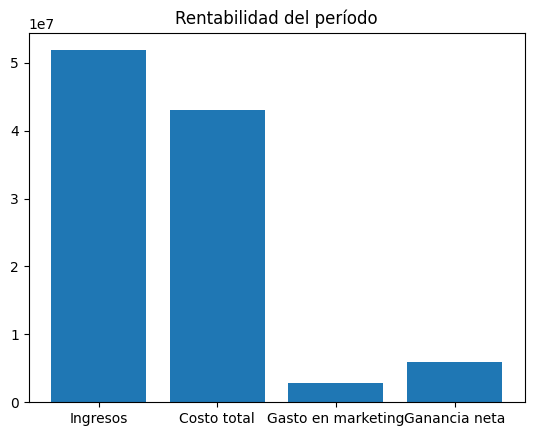

In [144]:
import matplotlib.pyplot as plt
#-------------------------------------------------------------------------------Evaluando el negocio---------------------------------------------------------------------------------


print('KPI´s\n')#------------------------------------------------------------------------------------KPI's principales---------------------------------------------------------------


print('\n\n                                                                                      Rentabilidad del negocio\n')
revenue = orders['monto_total'].sum()#---------------------------------------------------------------Total de ingresos
inversion = pd.merge(orders, catalog, how = 'inner', on = 'nombre_producto') #-----------------------Unión de datsets orders y catalog para calcular costo_total
inversion.columns #----------------------------------------------------------------------------------Verificando unión
inversion['costo_total'] = inversion['cantidad'] * inversion['costo_unitario'] 
costo_total = inversion['costo_total'].sum() #-------------------------------------------------------Total en costos
marketing_total = marketing['gasto'].sum() #---------------------------------------------------------Total de gastos en marketing
profit = (revenue - (costo_total + marketing_total)) #-----------------------------------------------Total de ganancia operativa
print('Ingresos = ', revenue)
print('\nCosto total = ', costo_total)
print('\nGasto en marketing = ', marketing_total)
print('\nGanancia neta = ', profit)
print('\n\n')

rentabilidad = ["Ingresos", "Costo total", "Gasto en marketing", "Ganancia neta"]
plt.bar(x = rentabilidad, height = [revenue, costo_total, marketing_total, profit], width=0.8, bottom=None, align='center', data=None)
plt.title('Rentabilidad del período')
plt.show()

**Interpretación:**  
El gráfico muestra los totales tanto de ingresos, costos, gasto en marketing y la ganancia neta. Se hace notar una similitud entre la barra de Ingresos y Costo total lo cual se debe a que durante el período se aprecia como varían los precios de venta, incluso por debajo del costo unitario de cada producto, llevando así a que la ganancia a fin del período tenga sólo un 11.36% en participación de los ingresos obtenidos.  Se recomienda analizar, revisar y ajustar la política de descuentos/precios en todos los casos, además verificar si el costo de cada producto se está adquiriendo por mayoreo a manera de que esta cifra no esté tan involucrada en la afectación de las ganancias.



                                                                        Comportamiento de ventas



                                                                        Cifras más altas en ingresos durante febrero



,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,año_mes
3726,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000,290.85,0.0,5817000.0,2025-02
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000,490.35,0.0,4903500.0,2025-02
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000,336.93,0.0,3369300.0,2025-02
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000,43.14,0.0,431400.0,2025-02




                                                                        Cifras más altas en ingresos durante abril



,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,año_mes
882,order_882,user_3970,2025-04-24,Colombia,desktop,organic,Phone-Pro-128GB,Electronica,2,499.69,0.0,999.38,2025-04
8319,order_8319,user_2114,2025-04-04,Colombia,desktop,social,Tablet-Standard-64GB,Electronica,2,499.62,0.0,999.24,2025-04
3208,order_3208,user_7792,2025-04-22,Colombia,mobile,organic,Phone-Pro-128GB,Electronica,2,499.11,0.0,998.22,2025-04
10199,order_10199,user_5788,2025-04-24,Colombia,mobile,organic,Laptop-Gaming-16GB,Electronica,2,498.17,0.0,996.33,2025-04


año_mes
2025-01     9967774.08
2025-02    15947906.95
2025-03     4443554.49
2025-04     1576806.71
2025-05    10467014.82
2025-06     9439673.84
Freq: M, Name: monto_total, dtype: float64

<AxesSubplot:title={'center':'Ingresos por mes'}, xlabel='Mes', ylabel='Ingresos'>

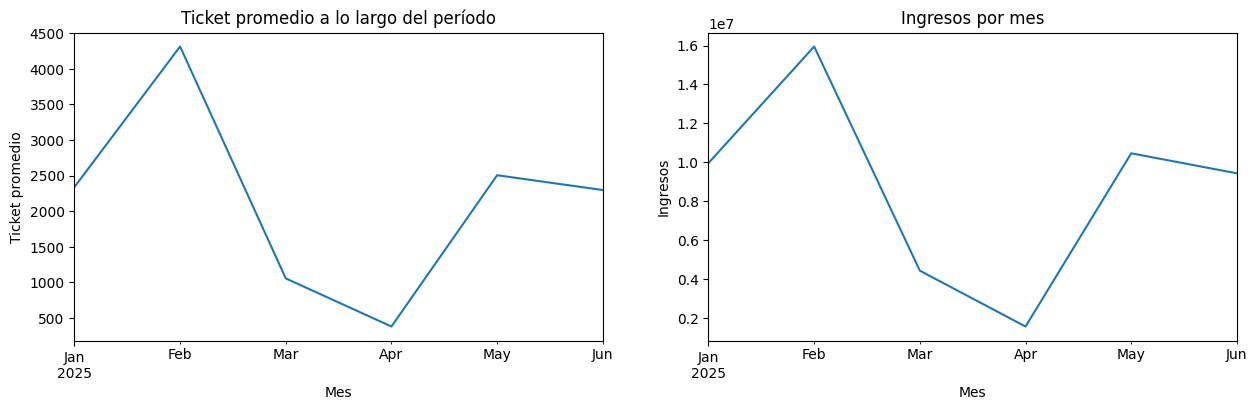

In [145]:
print('\n\n                                                                        Comportamiento de ventas\n')

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
orders['año_mes'] = orders['fecha_hora_pedido'].dt.to_period('M')
ticket_promedio = orders.groupby('año_mes')['monto_total'].mean() #-----------------------------------Ticket promedio por mes
print('\n\n                                                                        Cifras más altas en ingresos durante febrero\n')
display(orders[orders['año_mes'] == '2025-02'].nlargest(4, 'monto_total'))
print('\n\n                                                                        Cifras más altas en ingresos durante abril\n')
display(orders[orders['año_mes'] == '2025-04'].nlargest(4, 'monto_total'))
display(orders.groupby('año_mes')['monto_total'].sum())
ticket_promedio.plot(kind='line', ax = ax[0], title = 'Ticket promedio a lo largo del período', xlabel = 'Mes', ylabel = 'Ticket promedio')

ingresos_mes = orders.groupby('año_mes')['monto_total'].sum() #-------------------------------------------------------------Total de ingresos por mes
ingresos_mes.plot(kind = 'line', ax=ax[1], title = 'Ingresos por mes', xlabel = 'Mes', ylabel = 'Ingresos')

**Interpretación:**  
Febrero presenta el pico más alto debido a que existen 3 transacciones anómalas con el producto Laptop Gaming 16 GB con cifras de ganancias respecto al costo de venta que son de ~3%, +19% y ~75% , además de que también presenta una cifra anómala que disminuye las ganancias respecto al costo de venta con -85%, y para abril presenta el valle de todo el gráfico porque aquí predominan las trasacciones bajas, y además que no existen valores atípicos que distorcionen la forma del gráfico.



                                                                        Cifras más altas en cantidad de pedidos durante febrero



,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,año_mes
3726,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000,290.85,0.0,5817000.0,2025-02
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000,43.14,0.0,431400.0,2025-02
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000,490.35,0.0,4903500.0,2025-02
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000,336.93,0.0,3369300.0,2025-02




                                                                        Cifras más altas en cantidad de pedidos durante abril



,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,año_mes
15,order_15,user_1500,2025-04-03,Colombia,mobile,organic,Jacket-Winter-M,Moda,2,373.47,0.0,746.94,2025-04
38,order_38,user_4024,2025-04-23,Argentina,Desconocido,organic,Phone-Pro-128GB,Electronica,2,115.96,5.0,226.92,2025-04
425,order_425,user_6520,2025-04-20,Mexico,desktop,social,Vacuum-Pro-Black,Hogar,2,239.85,10.0,469.71,2025-04
426,order_426,user_7171,2025-04-21,Mexico,mobile,social,Tablet-Standard-64GB,Electronica,2,330.04,5.0,655.09,2025-04


año_mes
2025-01     8.531191
2025-02    15.028386
2025-03      3.88815
2025-04       1.4929
2025-05     6.294498
2025-06     8.802238
Freq: M, Name: cantidad, dtype: Float64

<AxesSubplot:title={'center':'Ingresos por mes'}, xlabel='Mes', ylabel='Ingresos'>

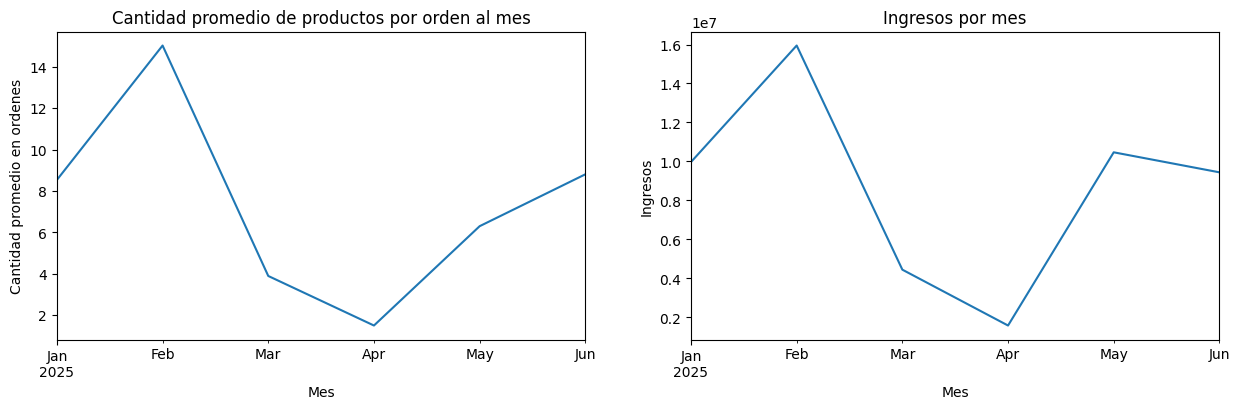

In [146]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))

mean_producto = orders.groupby('año_mes')['cantidad'].mean() #----------------------------------------Cantidad promedio de productos por orden por mes
print('\n\n                                                                        Cifras más altas en cantidad de pedidos durante febrero\n')
display(orders[orders['año_mes'] == '2025-02'].nlargest(4, 'cantidad'))
print('\n\n                                                                        Cifras más altas en cantidad de pedidos durante abril\n')
display(orders[orders['año_mes'] == '2025-04'].nlargest(4, 'cantidad'))
display(mean_producto)
mean_producto.plot(kind='line', ax = ax[0], title = 'Cantidad promedio de productos por orden al mes', xlabel = 'Mes', ylabel = 'Cantidad promedio en ordenes')

ingresos_mes.plot(kind = 'line', ax=ax[1], title = 'Ingresos por mes', xlabel = 'Mes', ylabel = 'Ingresos')

**Interpretación:**  
Dado que el gráfico muestra un pico en febrero y un valle en abril, esto se debe a que para el segundo mes del año se presentaron compras con cantidades atípicas desde 10,000 a 20,000 unidades forzando a la media a tomar un valor de 15.02, un 906.65% alejada de la cantidad de 1.4929 en el mes de abril. Y ya que con la  medida de tendencia central de promedio, observamos que con los valores atípicos no se describe el comportamiento normal de los clientes ese 906.65% sólo debe considerarse como un caso exclusivo y no como un patrón en el tiempo.

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,año_mes
3722,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000,442.01,0.0,8840200.00,2025-05
3668,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000,348.31,0.0,6966200.00,2025-06
3656,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electronica,20000,297.66,0.0,5953200.00,2025-01
3726,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000,290.85,0.0,5817000.00,2025-02
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000,490.35,0.0,4903500.00,2025-02
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000,336.93,0.0,3369300.00,2025-02
3522,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000,280.55,0.0,2805500.00,2025-03
3643,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000,238.15,0.0,2381500.00,2025-01
3689,order_3689,user_6566,2025-06-16,Mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000,87.69,0.0,876900.00,2025-06
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000,43.14,0.0,431400.00,2025-02


nombre_producto,Blender-XL-Red,Jacket-Winter-M,Laptop-Gaming-16GB,Phone-Pro-128GB,Sneakers-Urban-42,Tablet-Standard-64GB,Vacuum-Pro-Black
año_mes,,,,,,,
2025-01,270873.03,267887.58,8524322.76,171622.97,250306.75,189322.93,293438.06
2025-02,238941.01,233627.25,14692119.41,159526.81,244826.03,151293.42,227573.02
2025-03,273407.37,278280.00,2987613.26,202111.33,260316.04,182503.80,259322.69
2025-04,261670.77,270308.55,178314.82,171840.52,266873.84,166041.80,261756.41
2025-05,271245.05,273552.60,9015035.67,181123.02,263699.73,186958.74,275400.01
2025-06,272453.90,265115.93,8023735.94,159278.82,257669.65,174483.39,286936.21


<AxesSubplot:title={'center':'Ingresos por mes'}, xlabel='Mes', ylabel='Ingresos'>

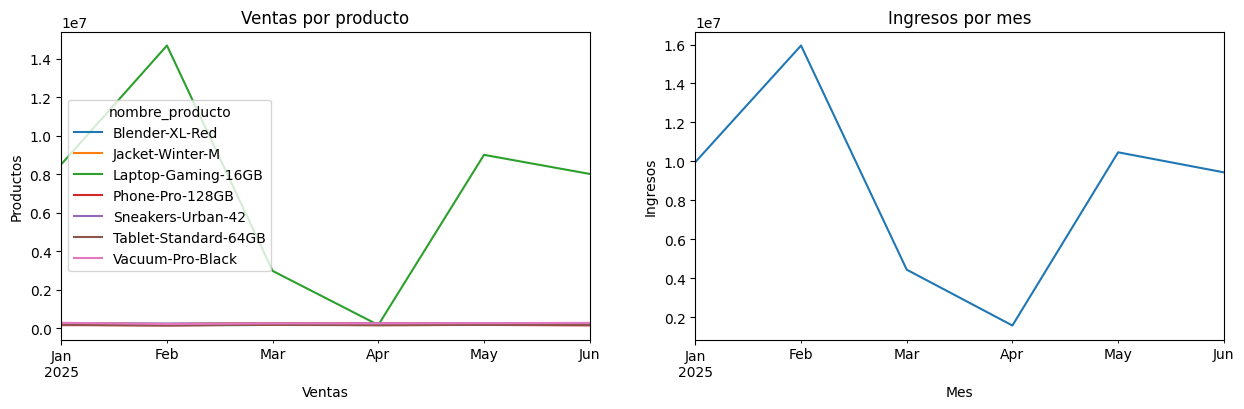

In [147]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))

bestseller = orders.groupby(['año_mes', 'nombre_producto'])['monto_total'].sum().unstack() #---------------------------------Producto más vendido
display(orders.nlargest(11, 'monto_total'))
display(bestseller)
bestseller.plot(kind = 'line', ax=ax[0], title = 'Ventas por producto', xlabel = 'Ventas', ylabel = 'Productos')

ingresos_mes.plot(kind = 'line', ax=ax[1], title = 'Ingresos por mes', xlabel = 'Mes', ylabel = 'Ingresos')#-----------------Total de ingresos por mes

**Interpretación:**  
El bestseller del período es Laptop Gaming 16 GB debido a que dentro de este lapso de tiempo en cuatro meses (enero, febrero, mayo y junio) tuvo ventas por encima de 10,000 unidades hasta las 20,000 unidades logrando recaudar el 83.75% en los ingresos totales. Esto nos lleva a anticipar que se está priorizando y creando dependencia de éste en un catálogo de siete productos, incluso que dentro de la categoría Electrónica a la cual pertenece, también existen otros dos productos. Se recomienda que la inversión en marketing tenga impacto en el resto de los productos.

canal,organic,paid_search,social
año_mes,,,
2025-01,166829.03,169958.93,163398.64
2025-02,143789.17,151279.21,153253.26
2025-03,175004.26,162848.15,178162.05
2025-04,151343.51,142923.58,150912.73
2025-05,178852.29,145847.19,174481.86
2025-06,156832.70,149517.14,156609.83


fuente_referencia,organic,paid_search,social
año_mes,,,
2025-01,6497986.87,547414.01,2922373.20
2025-02,3842816.51,5790168.04,6314922.40
2025-03,531605.77,557847.25,3354101.47
2025-04,514184.87,533380.73,529241.11
2025-05,543585.69,9384830.39,538598.74
2025-06,541978.84,8374322.10,523372.90


año_mes
2025-01     9967774.08
2025-02    15947906.95
2025-03     4443554.49
2025-04     1576806.71
2025-05    10467014.82
2025-06     9439673.84
Freq: M, Name: monto_total, dtype: float64

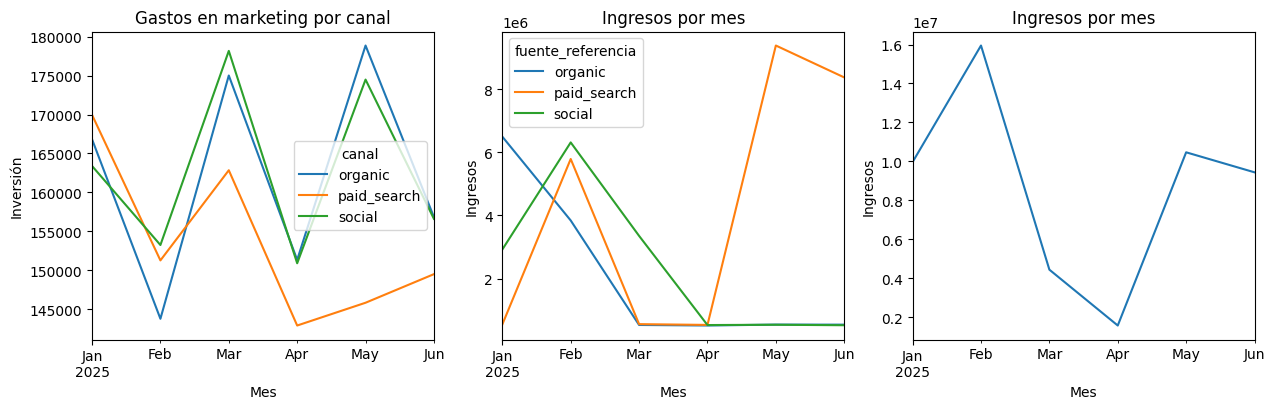

In [148]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

marketing['año_mes'] = marketing['fecha'].dt.to_period('M')
marketing_canal = marketing.groupby(['año_mes', 'canal'])['gasto'].sum().unstack() #----------------------------------------Total de gastos de marketing por canal
marketing_canal.plot(kind = 'line', ax = ax[0], title = 'Gastos en marketing por canal', xlabel = 'Mes', ylabel = 'Inversión')

ingresos_canal_mes = orders.groupby(['año_mes', 'fuente_referencia'])['monto_total'].sum().unstack() #-----------------------Total de ingresos por canal 
ingresos_canal_mes.plot(kind = 'line', ax = ax[1], title = 'Ingresos por mes', xlabel = 'Mes', ylabel = 'Ingresos')

ingresos_mes.plot(kind = 'line', ax = ax[2], title = 'Ingresos por mes', xlabel = 'Mes', ylabel = 'Ingresos') #--------------Total de ingresos por mes

display(marketing_canal)
display(ingresos_canal_mes)
ingresos_mes

**Interpretación:**  
Con el análisis de gastos en marketing por canal comparado con los ingresos a través del mismo y de manera complementaria los ingresos mes a mes del período, se concluye que el canal organic es el menos eficiente debido a su más alta inversión de 178,852.29 en mayo con ingresos = 543,585.69, obteniendo un gasto con porcentaje de 32.90% de los ingresos en el mismo mes, mientras que el canal que sí muestra eficiencia en el mismo mes es, paid_search, con una relación de gastos del 1.55%, con inversión de 145,847.19 y retorno de 9,384,830.39. También, para inicios del período entre enero y febrero social junto a paid_search tiene un pico con una similitud en relación gasto-ingreso con  2.43% (social) y 2.61% (paid_search

A pesar de la gran recuperación en 9,384,830.39 de paid_search en mayo los ingresos totales se ven afectados por el estancamiento de los otros dos canales a partir de marzo (organic) y abril (social). Dado que el pico de ingresos totales ocurrió en febrero con 15,947,906.95 debido a que los canales paid_search y social mostraron un pico simultaneo ayudando a mantener este mes como el más alto en todo el análisis, se recomienda reducir gasto en organic para invertir en estos dos canales.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>


Para el paso 2 lo ideal sería agregar las gráficas siguiendo el objetivo del paso y lo que le interesa a la empresa revisar. Siempre una gráfica es mucho mejor que sólo mostrar valores numéricos.

Pero para complementar esta parte también puedes agregar tu interpretación de las gráficas mostradas en una celda markdown.

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Correcto, siempre es importante tener un proceso de análisis claro y fácil de entender en todos tus notebooks para que cuando alguien de tu equipo quiera reproducir tu trabajo puedan entenderlo facilmente.
</div>

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [149]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [150]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con = engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


,cantidad_usuarios,nombre_evento
0,7796,first_visit
1,7582,select_item
2,7634,add_to_cart
3,7208,begin_checkout
4,6250,add_payment_info
5,6240,purchase


Text(0, 0.5, 'Etapa del funnel')

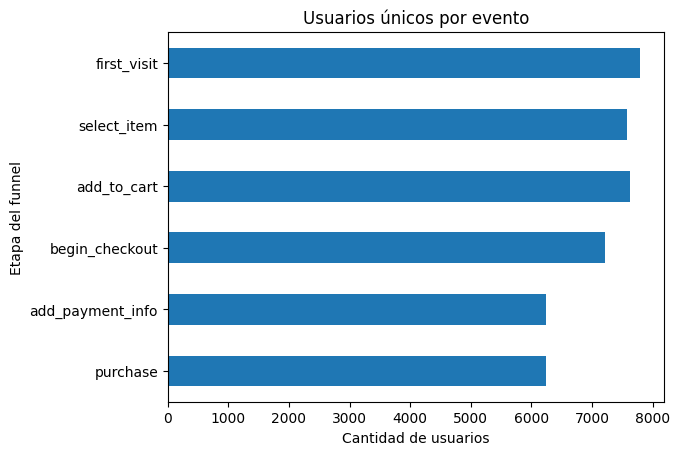

In [151]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT COUNT(DISTINCT id_usuario) AS cantidad_usuarios,
       nombre_evento
FROM events
GROUP BY nombre_evento
ORDER BY (CASE 
                    WHEN nombre_evento = 'first_visit' THEN 1
                    WHEN nombre_evento = 'select_item' THEN 2
                    WHEN nombre_evento = 'add_to_cart' THEN 3
                    WHEN nombre_evento = 'begin_checkout' THEN 4
                    WHEN nombre_evento = 'add_payment_info' THEN 5
                    WHEN nombre_evento = 'purchase' THEN 6
                ELSE 0
                END
            )
'''

totals = pd.read_sql(query_totals, con=engine)
display(totals)

import matplotlib.pyplot as plt
funnel = totals.groupby('nombre_evento')['cantidad_usuarios'].sum().reindex(['first_visit', 'select_item', 'add_to_cart', 'begin_checkout', 'add_payment_info', 'purchase']).iloc[::-1]
funnel.plot(kind = 'barh')
plt.title('Usuarios únicos por evento')
plt.xlabel('Cantidad de usuarios')
plt.ylabel('Etapa del funnel')

,cantidad_usuarios,nombre_evento
0,7796,first_visit
1,7582,select_item
2,7634,add_to_cart
3,7208,begin_checkout
4,6250,add_payment_info
5,6240,purchase


,tasas_conversion
tasa_first_visit_select_item,97.255003
tasa_select_item_add_to_cart,100.685835
tasa_add_to_cart_begin_checkout,94.419701
tasa_begin_checkout_add_payment_info,86.709212
tasa_add_payment_info_purchase,99.840000
tasa_final,80.041047


Text(0, 0.5, 'Pasos del funnel')

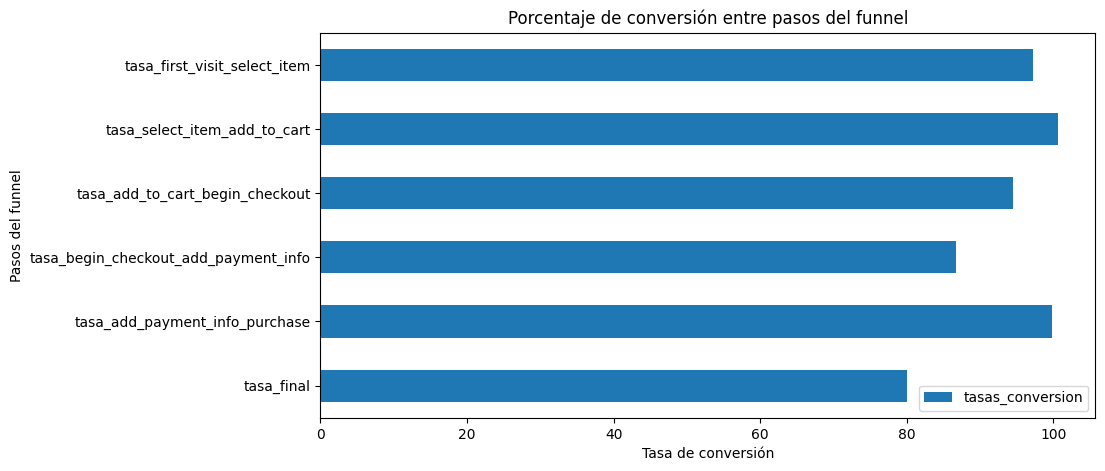

In [152]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''

WITH first_visit AS (
  SELECT COUNT(DISTINCT id_usuario) AS usuarios_first_visit
  FROM events
  WHERE nombre_evento = 'first_visit'   
),
  select_item AS (  
  SELECT COUNT(DISTINCT id_usuario) AS usuarios_select_item
  FROM events
  WHERE nombre_evento = 'select_item'   
),
  add_to_cart AS (
  SELECT COUNT(DISTINCT id_usuario) AS usuarios_add_to_cart
  FROM events
  WHERE nombre_evento = 'add_to_cart'   
),
  begin_checkout AS (
  SELECT COUNT(DISTINCT id_usuario) AS usuarios_begin_checkout
  FROM events
  WHERE nombre_evento = 'begin_checkout'   
),
  add_payment_info AS (
  SELECT COUNT(DISTINCT id_usuario) AS usuarios_add_payment_info
  FROM events
  WHERE nombre_evento = 'add_payment_info'   
),
  purchase AS (
  SELECT COUNT(DISTINCT id_usuario) AS usuarios_purchase
  FROM events
  WHERE nombre_evento = 'purchase'   
)
SELECT
    usuarios_first_visit,
    usuarios_select_item,
    usuarios_add_to_cart,
    usuarios_begin_checkout,
    usuarios_add_payment_info,
    usuarios_purchase,
    usuarios_select_item * 100.0 / NULLIF(usuarios_first_visit, 0) AS tasa_first_visit_select_item,
    usuarios_add_to_cart * 100.0 / NULLIF(usuarios_select_item, 0) AS tasa_select_item_add_to_cart,
    usuarios_begin_checkout * 100.0 / NULLIF(usuarios_add_to_cart, 0) AS tasa_add_to_cart_begin_checkout,
    usuarios_add_payment_info * 100.0 / NULLIF(usuarios_begin_checkout, 0) AS tasa_begin_checkout_add_payment_info,
    usuarios_purchase * 100.0 / NULLIF(usuarios_add_payment_info, 0) AS tasa_add_payment_info_purchase,
    (usuarios_purchase * 100.0) / usuarios_first_visit AS tasa_final
FROM first_visit, select_item, add_to_cart, begin_checkout, add_payment_info, purchase


WHERE usuarios_first_visit > ALL (
    SELECT usuarios_select_item FROM select_item
    UNION ALL
    SELECT usuarios_add_to_cart FROM add_to_cart
    UNION ALL
    SELECT usuarios_begin_checkout FROM begin_checkout
    UNION ALL
    SELECT usuarios_add_payment_info FROM add_payment_info
    UNION ALL
    SELECT usuarios_purchase FROM purchase
    ) 

'''

conversion = pd.read_sql(query_conversion, con=engine)
display(totals)
import matplotlib.pyplot as plt
tasas_funnel = conversion[['tasa_first_visit_select_item', 'tasa_select_item_add_to_cart', 'tasa_add_to_cart_begin_checkout', 'tasa_begin_checkout_add_payment_info', 'tasa_add_payment_info_purchase', 'tasa_final']] 
tasas_funnel = tasas_funnel.loc[[0]].T.iloc[::-1].rename(columns ={0: 'tasas_conversion'})
display(tasas_funnel.iloc[::-1])
tasas_funnel.plot(kind = 'barh', figsize = (10, 5))
plt.title('Porcentaje de conversión entre pasos del funnel')
plt.xlabel('Tasa de conversión')
plt.ylabel('Pasos del funnel')

---

**Interpretación:**  
Con el análisis de las etapas first_visit, select_item, add_to_cart, begin_checkout, add_payment_info y purchase en el embudo de RappiPlus, se determina que la tasa de conversión acumulada de usuarios es del 80.04%. Se identifica el mayor drop off en las etapas begin_checkout a add_payment_info con una tasa de conversión = 86.70% donde las causas de que los usuarios se pierdan podrían ser debido a costos de envío, el proceso de registro es muy extenso, o el usuario pensó que sólo sería añadir el producto, pagar y recibir. Además para este funnel la etapa con la tasa de conversión más alta es entre select_item a add_to_cart, donde incluso supera el 100%, razón que se puede explicar debido a la limitación de secuencialidad.

Para este análisis se recomienda realizar un cruce de información entre país y dispositivo donde los usuarios iniciaron sesión para verificar o descartar las hipótesis donde surge el mayor drop off en el funnel y entender la anomalía de por qué existe un aumento de clientes en la etapa select_item a add_to_cart.


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>


Perfecto el cálculo realizado sobre las conversiones. Aquí lo único que agregaría sería una visualización para complementar los resultados y que sea más sencillo explicar los resultados obtenidos del funnel.

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Bien, siempre hay que asegurarse de que las métricas presentadas sean las correctas ya qu eso es vital para una toma de decisiones adecuada en la empresa
</div>

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [153]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [154]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


,mes_cohorte,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01,697,668,656,42.8,41.1,40.3
1,2025-02,611,609,635,42.3,42.2,44.0
2,2025-03,677,705,690,41.4,43.1,42.2
3,2025-04,680,697,663,42.3,43.4,41.3
4,2025-05,695,676,706,41.2,40.1,41.8


,Cohorte_1,Cohorte_2,Cohorte_3,Cohorte_4,Cohorte_5
semana_1,42.8,42.3,41.4,42.3,41.2
semana_2,41.1,42.2,43.1,43.4,40.1
semana_3,40.3,44.0,42.2,41.3,41.8


<AxesSubplot:>

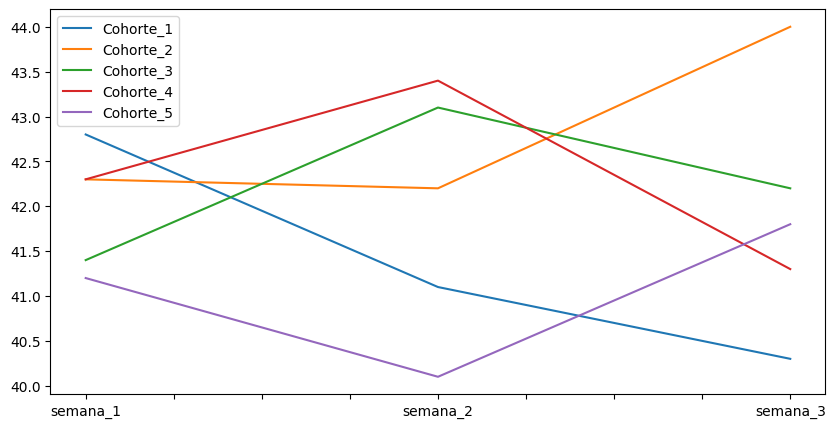

In [155]:
# Retención por cohortes
# ======================
query_cohort_retention_final = '''
SELECT
    TO_CHAR(DATE_TRUNC('month', CAST(u.fecha_registro AS DATE)), 'YYYY-MM') AS mes_cohorte,
    
    COUNT(DISTINCT CASE WHEN a.activo = 1 AND a.dias_despues_registro = 7 THEN u.id_usuario END) AS retenido_W1,
    COUNT(DISTINCT CASE WHEN a.activo = 1 AND a.dias_despues_registro = 14 THEN u.id_usuario END) AS retenido_W2,
    COUNT(DISTINCT CASE WHEN a.activo = 1 AND a.dias_despues_registro = 21 THEN u.id_usuario END) AS retenido_W3,
   
    
    ROUND(COUNT(DISTINCT CASE WHEN a.activo = 1 AND a.dias_despues_registro = 7 THEN u.id_usuario END) * 100.0 / NULLIF(COUNT(DISTINCT u.id_usuario), 0), 1)  AS semana_1,
    ROUND(COUNT(DISTINCT CASE WHEN a.activo = 1 AND a.dias_despues_registro = 14 THEN u.id_usuario END) * 100.0 / NULLIF(COUNT(DISTINCT u.id_usuario), 0), 1)  AS semana_2,
    ROUND(COUNT(DISTINCT CASE WHEN a.activo = 1 AND a.dias_despues_registro = 21 THEN u.id_usuario END) * 100.0 / NULLIF(COUNT(DISTINCT u.id_usuario), 0), 1)  AS semana_3

FROM users u
INNER JOIN user_activity a ON u.id_usuario = a.id_usuario
GROUP BY (mes_cohorte)
    
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final.set_index('mes_cohorte')
display(cohorte_final)
porcentajes_cohorte = cohorte_final[['semana_1', 'semana_2', 'semana_3']].T
porcentajes_cohorte = porcentajes_cohorte.rename(columns = {0 : 'Cohorte_1', 1 : 'Cohorte_2', 2 : 'Cohorte_3', 3 : 'Cohorte_4', 4 : 'Cohorte_5'})
display(porcentajes_cohorte)
porcentajes_cohorte.plot(kind = 'line', figsize = (10, 5))

---

**Interpretación:**  
En el análisis de retención de usuarios de RappiPlus, a nivel general existe un nivel estable entre cohortes del 40% al 44%, donde en el transcurso de las semanas de cada cohorte se presentan caídas insignificantes. Cabe mencionar que como valor atípico se tiene a la cohorte del mes cuatro:  
  
Mes 1 - 1.25% de la semana 1 a la semana 3  
Mes 2 - 0.1% de la semana 1 a la semana 2  
Mes 3 - 0.9 de la semana 2 a la semana 3  
Mes 4 - 2.1% de la semana 2 a la semana 3  
Mes 5 - 1.1% de la semana 1 a la semana 2

Para la cohorte del mes cuatro donde la caída porcentual es de 2.1%, se recomienda plantear un análisis para saber que sucedió en el transcurso de esas semanas y tomar acción como medida de prevención a que el evento sucedido no pueda afectar de manera significativa la retención de los usuarios. Además de rescatar que el mes dos es el más estable debido a que con un 0.1% en caída porcentual, y un cierre en la semana 3 con un 44% (valor porcentual más altos en el análisis), lo cual podría llevar a analizar este período en cuestión de marketing, políticas de descuento en productos, o alguna mejora en la plataforma que redujera el patrón de pérdida semana a semana del mes uno.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

La query está muy bien y estás obteniendo resultados adecuados pero lo complementarías mejor si agregaras una visualización.
</div>

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** La tasa de conversión del grupo tratamiento es igual a la tasa de conversión del grupo control (no hay diferencia).
   - **H₁ (Hipótesis alternativa):** La tasa de conversión del grupo tratamiento es diferente a la tasa de conversión del grupo control (sí hay diferencia).
   
**Test estadístico:** chi-cuadrada  
**Nivel de significancia alpha:** α = 0.05

In [156]:
#--------------------------------------------------------------------------------Validando si los cambios generan impacto------------------------------------------------------------

from scipy.stats import chi2_contingency #-----------------------------------------------------------------------------------importando librería para estadístico chi-cuadrada
experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
display(experiment.head()) #-------------------------------------------------------------------------------------------------Explorando dataset de UI del checkout

tabla = pd.crosstab(experiment['variante'], experiment['convirtio']) #-------------------------------------------------------Creación de tabla de contingencia
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"\nEstadístico chi-cuadrado: {chi2_stat}")
print(f"Valor P: {p_value}")

print(f"\nTabla normalizada\n{pd.crosstab(experiment['variante'], experiment['convirtio'], normalize = 'index') * 100}") #---Creación de tabla normalizada
print('\n', experiment['variante'].value_counts())


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12



Estadístico chi-cuadrado: 0.6177857659309294
Valor P: 0.43187130118526496

Tabla normalizada
convirtio            0          1
variante                         
control      84.310171  15.689829
tratamiento  83.714002  16.285998

 tratamiento    5035
control        4965
Name: variante, dtype: int64


**Interpretación**  
El análisis arroja un valor p = 0.431 > alpha (0.05), con ello no se rechaza la hipótesis nula debido a que no existe diferencia estadísticamente significativa entre la tasa de conversión del grupo tratamiento y la tasa de conversión del grupo control. Se observa que el rango de conversión es insignificante dado que los usuarios en control convirtieron en 15.68% y los usuarios en tratamiento 16.28%, esto podría deberse únicamente al azar a causa de que para la hipótesis nula acertada no existe evidencia suficiente para poder demostrar qué variante muestra mayor probabilidad de conversión dentro del contexto analizado. Además la muestra por el momento es pequeña, apenas 10,000 usuarios, si el experimento apenas comienza dejar que siga acumulando datos no en tiempo, sino en cantidad de datos acumulados (50,000 como minímo) para un futuro análisis y por el momento tener la certeza de que ambos están teniendo resultados parecidos.

De esta manera se recomienda no modificar el diseño del experimento (tamaño de muestra objetivo, duración, criterios de asignación) a manera de evitar introducir sesgos que invaliden la comparación entre control y tratamiento hasta llegar a la cifra citada para un nuevo análisis de conversión. Cabe mencionar que para este punto no existe análisis para definir si la retención tiene efecto sobre la conversión.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien aplicadas las pruebas estadísticas, esto ayuda a demostrar que las diferencias observadas son significativas y no un evento aislado en la observación.
</div>

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## Conclusiones  

- La ganancia es solo el 11.36% de los ingresos.  

- El comportamiento de las ventas proviene del prodcuto Laptop Gaming 16 GB que representa el 83.75% de los ingresos de todo el período, y el canal paid search tiene la mejor eficiencia con dos relaciones gasto-ingresos muy pequeñas; una en febrero del 2.61% y otra en mayo del 1.55%.  

- La tasa acumulada de conversión del funnel es del 80.04%, y el paso entre etapas con la tase de conversión de usuarios más baja, es de degin checkout a add payment info.  

- La retención de usuarios por semana es estable, normalmente las tasas rondan entre 40% y 44%.  

- El test estadístico demuestra que no se encontró evidencia estadísticamente significativa de una diferencia entre las tasas de conversión de compra entre el grupo control y el grupo tratamiento.

## Recomendaciones generales

- Analizar, revisar y ajustar la política de descuentos/precios en todos los casos, además verificar si el costo de cada producto se está adquiriendo por mayoreo a manera de que esta cifra no esté tan involucrada en la afectación de las ganancias.
- Invertir en marketing para tener impacto en el resto de los productos, no sólo en Laptop Gaming 16GB. También reducir gasto de campaña en organic para invertir en los canales paid_search y social que mostraron eficiencia en el período.
- Realizar un cruce de información entre país y dispositivo donde los usuarios iniciaron sesión para verificar o descartar las hipótesis (usuarios se pierdan debido a costos de envío, el proceso de registro es muy extenso, o el usuario pensó que sólo sería añadir el producto, pagar y recibir) donde surge el mayor drop off en el funnel y entender la anomalía de por qué existe un aumento de clientes en la etapa select_item a add_to_cart.
- Plantear un análisis para saber que sucedió en el transcurso de las semanas de la cohorte 4 y tomar acción como medida de prevención a que el evento sucedido no pueda afectar de manera significativa la retención de los usuarios.
- No modificar el diseño del experimento (tamaño de muestra objetivo, duración, criterios de asignación) a manera de evitar introducir sesgos que invaliden la comparación entre control y tratamiento hasta llegar a la cifra citada para un nuevo análisis de conversión. Cabe mencionar que para este punto no existe análisis para definir si la retención tiene efecto sobre la conversión.






## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

**Link de Google Drive**  
https://drive.google.com/drive/folders/1isiNn-u_a6QIMTDOF870jMVlUTLgiDgA?usp=sharing

<div class="alert alert-block alert-danger">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen avance de tu proyecto en cuanto a código Juan. Hay algunos puntos con oportunidades de mejora donde te he dejado algunos comentarios.

También, al final deberías tener una sección con conclusiones y recomendaciones generales que puedas darle a la empresa en base a los diferentes pasos realizados a lo largo de tu notebook.

Si tienes dudas o dificultades recuerda que puedes contactar a tu Success Manager o a tu tutor para solventarlas.

Saludos!
</div>

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Juan!** 

El paso a paso seguido en el proceso de análisis del proyecto quedó super claro y se ajusta a las necesidades del negocio presentadas. Recuerda que un buen análisis siempre debe tener una buena parte técnica que ayude a comprender la parte de negocio y los beneficios del mismo.

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>